In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

import scipy.stats as stats

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
dmnds = pd.read_csv('diamonds.csv')

In [ ]:
dmnds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
dmnds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [ ]:
dmnds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


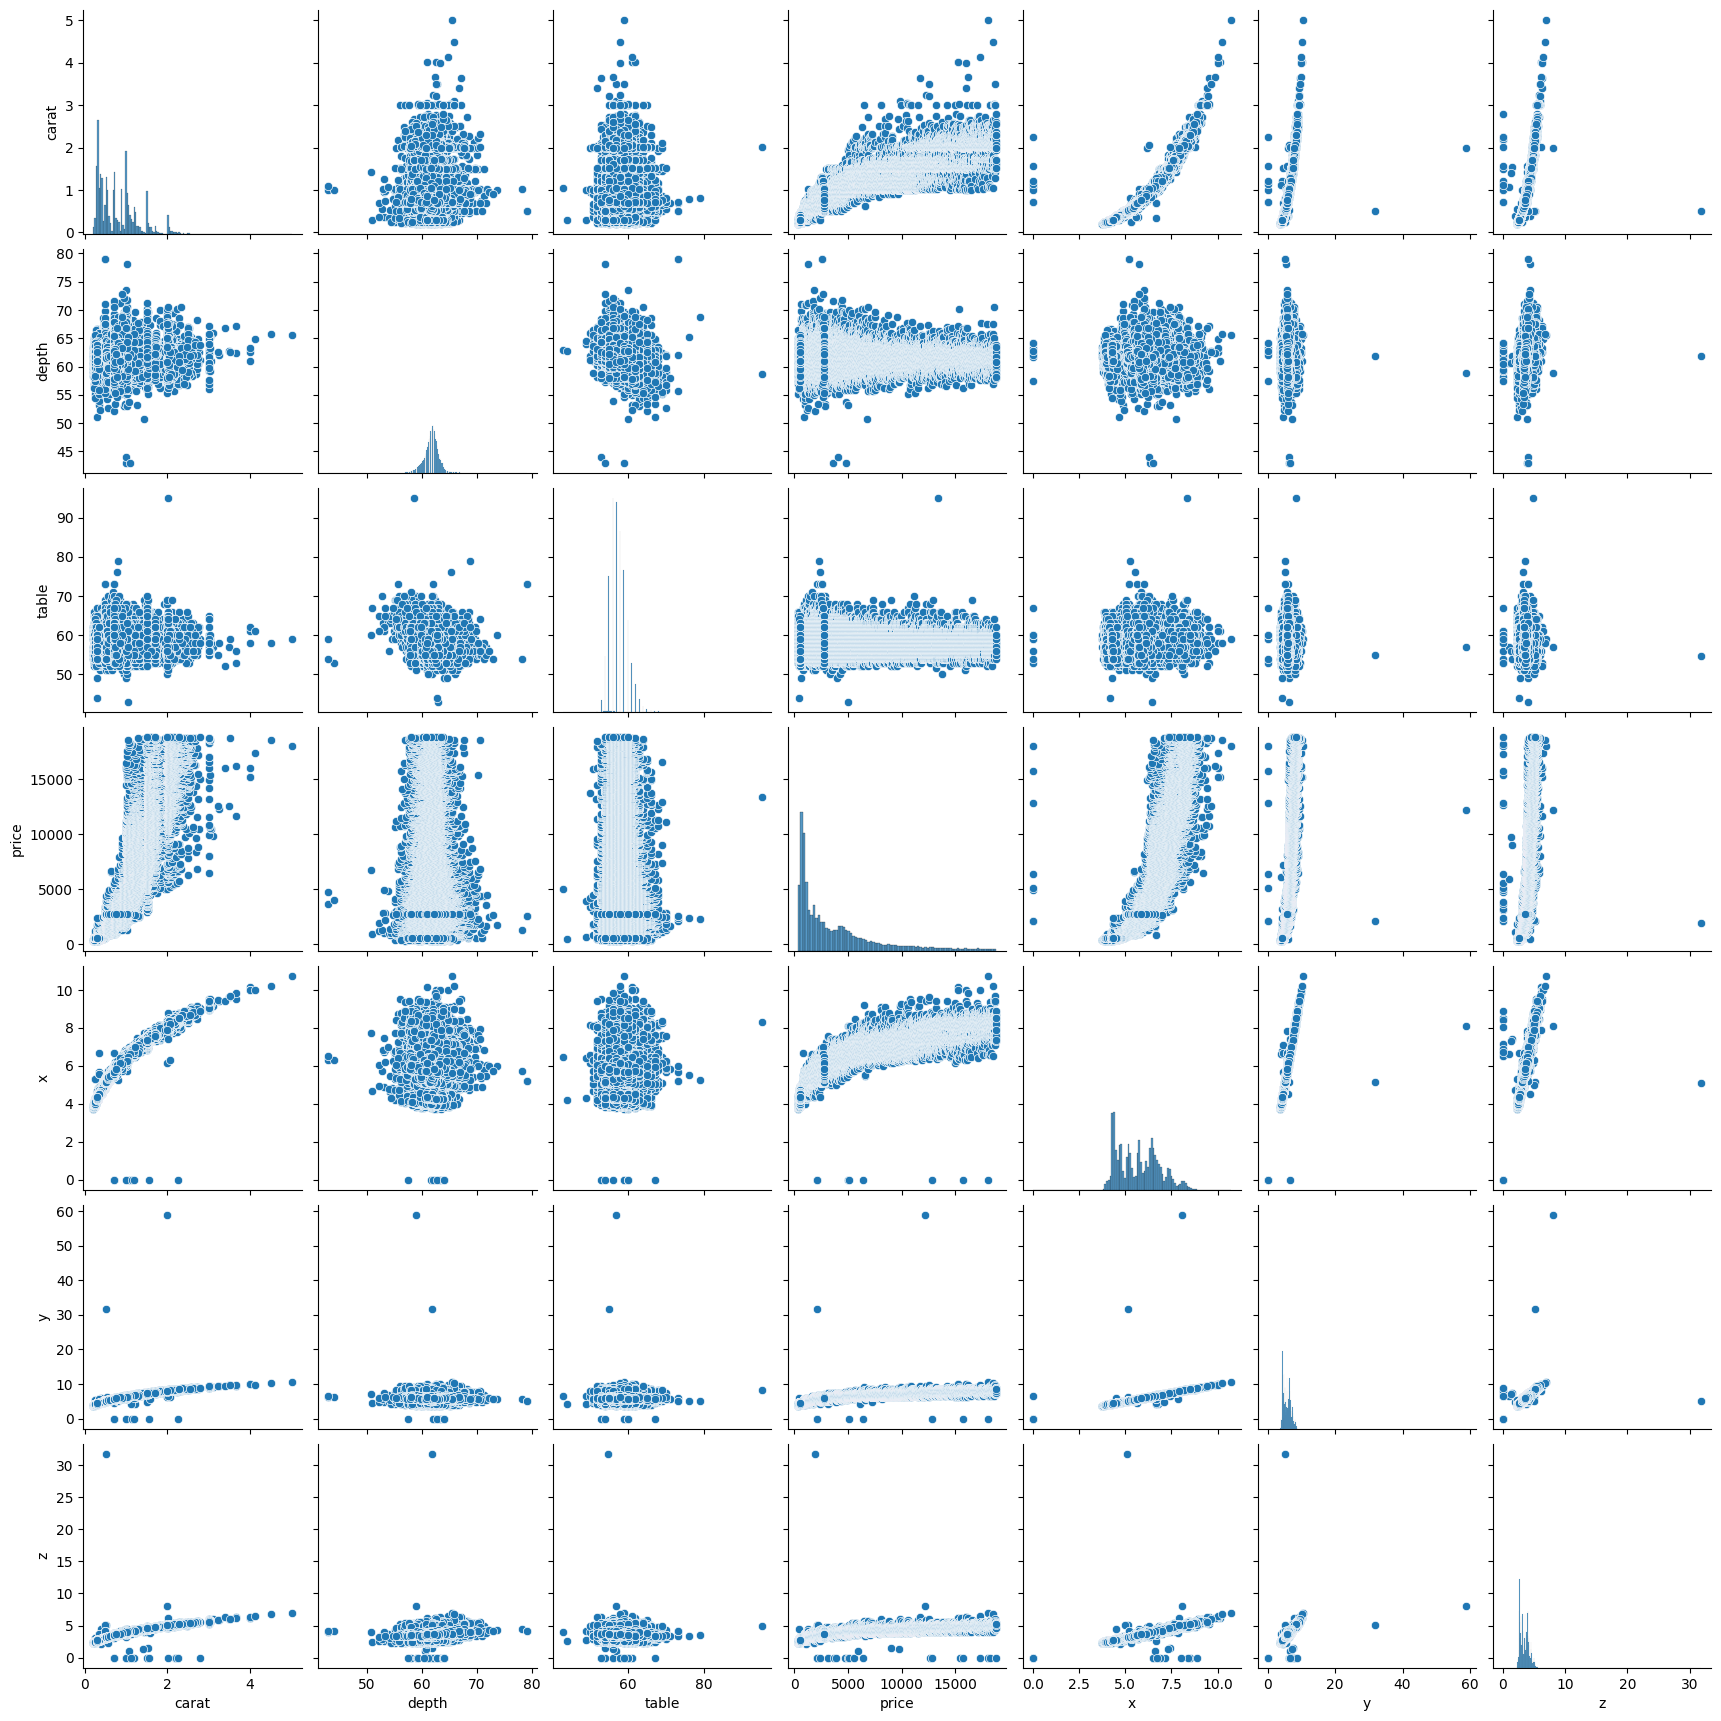

In [ ]:
sns.pairplot(dmnds)
plt.show()

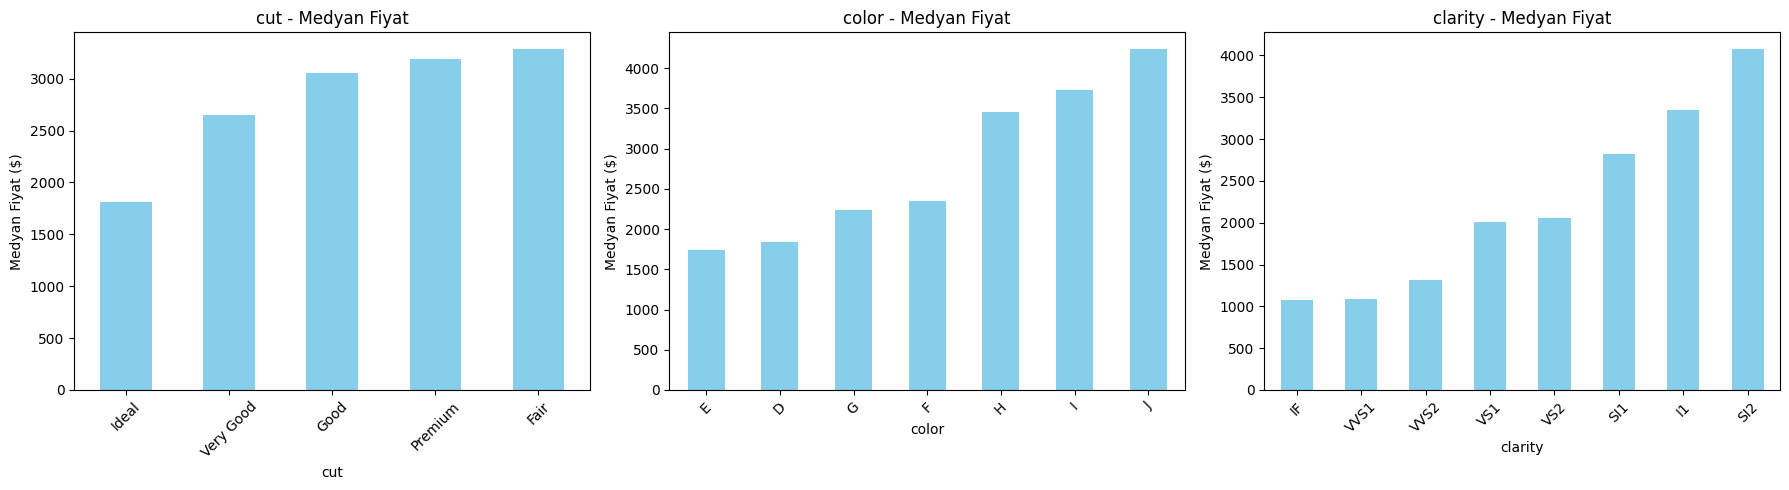

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_cols = ['cut', 'color', 'clarity']
for i, col in enumerate(cat_cols):
  dmnds.groupby(col)['price'].median().sort_values().plot(kind='bar', ax=axes[i], color='skyblue')
  axes[i].set_title(f'{col} - Medyan Fiyat')
  axes[i].set_ylabel('Medyan Fiyat ($)')
  axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']

clarity_order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

dmnds['color'] = dmnds['color'].astype(pd.CategoricalDtype(categories=color_order, ordered=True))
dmnds['clarity'] = dmnds['clarity'].astype(pd.CategoricalDtype(categories=clarity_order, ordered=True))

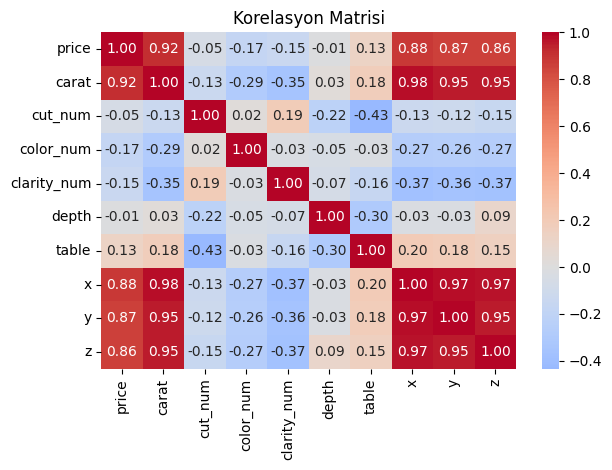

In [ ]:
dmnds['cut_num'] = dmnds['cut'].map({'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5})
dmnds['color_num'] = dmnds['color'].map({'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7})
dmnds['clarity_num'] = dmnds['clarity'].map({'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5, 'VVS2':6, 'VVS1':7, 'IF':8})

cols = ['price', 'carat', 'cut_num', 'color_num', 'clarity_num', 'depth', 'table', 'x', 'y', 'z']

corr = dmnds[cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

In [ ]:
print("x=0 olan satır sayısı:", (dmnds['x'] == 0).sum())
print("y=0 olan satır sayısı:", (dmnds['y'] == 0).sum())
print("z=0 olan satır sayısı:", (dmnds['z'] == 0).sum())

print("\n0 değeri içeren satırlar:")
print(dmnds[(dmnds['x'] == 0) | (dmnds['y'] == 0) | (dmnds['z'] == 0)])


x=0 olan satır sayısı: 8
y=0 olan satır sayısı: 7
z=0 olan satır sayısı: 20

0 değeri içeren satırlar:
       carat        cut color clarity  depth  table  price     x     y    z  \
2207    1.00    Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0   
2314    1.01    Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0   
4791    1.10    Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0   
5471    1.01    Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0   
10167   1.50       Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0   
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.00  6.62  0.0   
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00  0.00  0.0   
13601   1.15      Ideal     G     VS2   59.2   56.0   5564  6.88  6.83  0.0   
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.00  0.00  0.0   
24394   2.18    Premium     H     SI2   59.4   61.0  12631  8.49  8.45  0.0   
24520   1.56      Ideal     

In [ ]:
dmnds = dmnds[dmnds['x'] > 0]
dmnds = dmnds[dmnds['y'] > 0]
dmnds = dmnds[dmnds['z'] > 0]

In [ ]:
print("x=0 olan satır sayısı:", (dmnds['x'] == 0).sum())
print("y=0 olan satır sayısı:", (dmnds['y'] == 0).sum())
print("z=0 olan satır sayısı:", (dmnds['z'] == 0).sum())

print("\n0 değeri içeren satırlar:")
print(dmnds[(dmnds['x'] == 0) | (dmnds['y'] == 0) | (dmnds['z'] == 0)])


x=0 olan satır sayısı: 0
y=0 olan satır sayısı: 0
z=0 olan satır sayısı: 0

0 değeri içeren satırlar:
Empty DataFrame
Columns: [carat, cut, color, clarity, depth, table, price, x, y, z, cut_num, color_num, clarity_num]
Index: []


In [ ]:
print(dmnds[dmnds.duplicated()])
dmnds = dmnds.drop_duplicates()
print(dmnds[dmnds.duplicated()])

       carat    cut color clarity  depth  table  price     x     y     z  \
1005    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66   
1006    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66   
1007    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66   
1008    0.79  Ideal     G     SI1   62.3   57.0   2898  5.90  5.85  3.66   
2025    1.52   Good     E      I1   57.3   58.0   3105  7.53  7.42  4.28   
...      ...    ...   ...     ...    ...    ...    ...   ...   ...   ...   
47296   0.30   Good     J     VS1   63.4   57.0    394  4.23  4.26  2.69   
47969   0.52  Ideal     D     VS2   61.8   55.0   1919  5.19  5.16  3.20   
49326   0.51  Ideal     F    VVS2   61.2   56.0   2093  5.17  5.19  3.17   
50079   0.51  Ideal     F    VVS2   61.2   56.0   2203  5.19  5.17  3.17   
52861   0.50   Fair     E     VS2   79.0   73.0   2579  5.21  5.18  4.09   

       cut_num color_num clarity_num  
1005         5         4           3  
1006     

In [ ]:
dmnds.shape

(53775, 13)

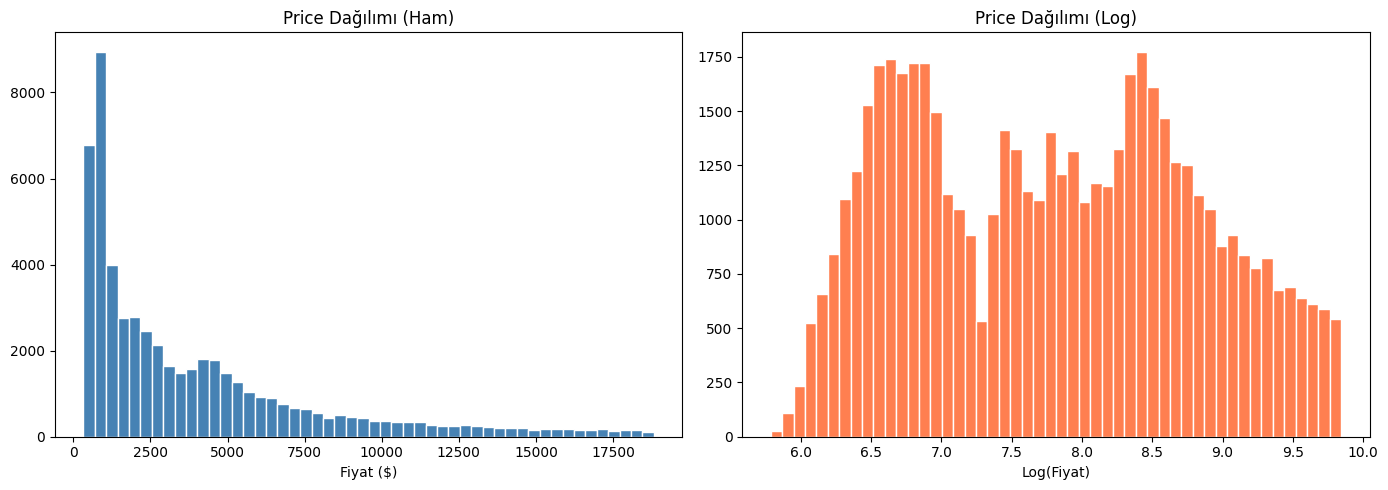

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dmnds['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Dağılımı (Ham)')
axes[0].set_xlabel('Fiyat ($)')

axes[1].hist(np.log(dmnds['price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Price Dağılımı (Log)')
axes[1].set_xlabel('Log(Fiyat)')

plt.tight_layout()
plt.show()

In [ ]:
dmnds['log_price'] = np.log(dmnds['price'])

In [ ]:
dmnds.describe()

,carat,depth,table,price,x,y,z,cut_num,log_price
count,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000
mean,0.797536,61.748232,57.457806,3931.220288,5.731579,5.734909,3.539964,3.904231,7.786759
std,0.473169,1.429639,2.233257,3985.918716,1.118611,1.139451,0.702017,1.116097,1.014320
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,1.000000,5.786897
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000,3.000000,6.857514
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,4.000000,7.783641
75%,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.030000,5.000000,8.579980
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,5.000000,9.842835


In [ ]:
dmnds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,cut_num,color_num,clarity_num,log_price
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,5,6,2,5.786897
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,4,6,3,5.786897
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,2,6,5,5.789960
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,4,2,4,5.811141
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,2,1,2,5.814131


In [ ]:
cols = ['carat', 'x', 'y', 'z', 'cut_num', 'color_num', 'clarity_num', 'log_price', 'price']
dmnds[cols].corr()

,carat,x,y,z,cut_num,color_num,clarity_num,log_price,price
carat,1.000000,0.977857,0.953980,0.961030,-0.133351,-0.290943,-0.352194,0.920417,0.921548
x,0.977857,1.000000,0.974822,0.975382,-0.124773,-0.270228,-0.372290,0.960753,0.887137
y,0.953980,0.974822,1.000000,0.956623,-0.120761,-0.263455,-0.358440,0.938386,0.867685
z,0.961030,0.975382,0.956623,1.000000,-0.149064,-0.269584,-0.369669,0.941748,0.868030
cut_num,-0.133351,-0.124773,-0.120761,-0.149064,1.000000,0.020149,0.188337,-0.086329,-0.052225
color_num,-0.290943,-0.270228,-0.263455,-0.269584,0.020149,1.000000,-0.025702,-0.154350,-0.171746
clarity_num,-0.352194,-0.372290,-0.358440,-0.369669,0.188337,-0.025702,1.000000,-0.212807,-0.146124
log_price,0.920417,0.960753,0.938386,0.941748,-0.086329,-0.154350,-0.212807,1.000000,0.895767
price,0.921548,0.887137,0.867685,0.868030,-0.052225,-0.171746,-0.146124,0.895767,1.000000


In [ ]:
dmnds = dmnds.drop(columns=[ 'x', 'y', 'z'])

In [ ]:
dmnds.head()

,carat,cut,color,clarity,depth,table,price,cut_num,color_num,clarity_num,log_price
0,0.23,Ideal,E,SI2,61.5,55.0,326,5,6,2,5.786897
1,0.21,Premium,E,SI1,59.8,61.0,326,4,6,3,5.786897
2,0.23,Good,E,VS1,56.9,65.0,327,2,6,5,5.789960
3,0.29,Premium,I,VS2,62.4,58.0,334,4,2,4,5.811141
4,0.31,Good,J,SI2,63.3,58.0,335,2,1,2,5.814131


/tmp/ipykernel_7747/3214531883.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  color_medians = dmnds.groupby('color')['price'].median().reindex(color_order)
/tmp/ipykernel_7747/3214531883.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clarity_medians = dmnds.groupby('clarity')['price'].median().reindex(clarity_order)


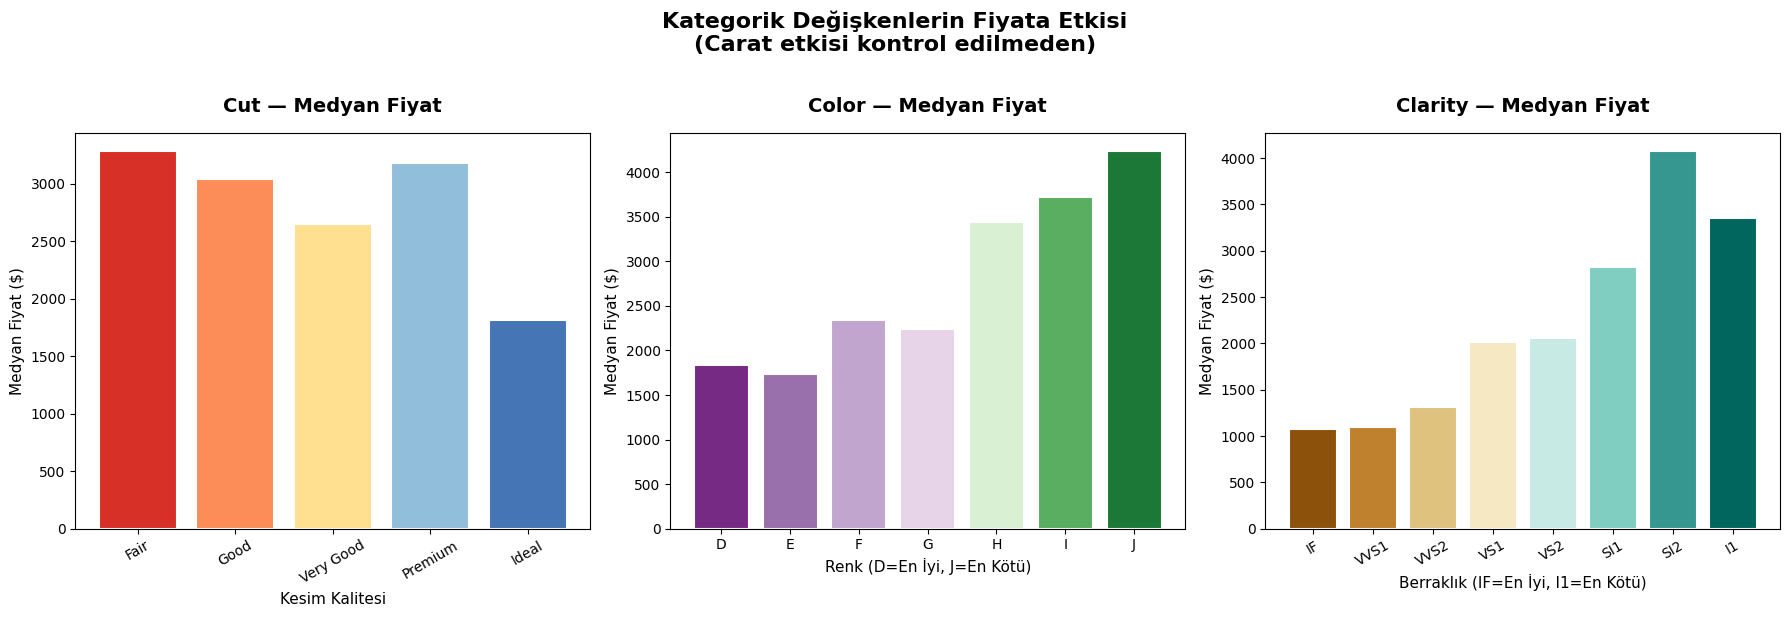

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors_cut = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
colors_color = ['#762a83', '#9970ab', '#c2a5cf', '#e7d4e8', '#d9f0d3', '#5aae61', '#1b7837']
colors_clarity = ['#8c510a', '#bf812d', '#dfc27d', '#f6e8c3', '#c7eae5', '#80cdc1', '#35978f', '#01665e']

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
cut_medians = dmnds.groupby('cut')['price'].median().reindex(cut_order)
axes[0].bar(cut_order, cut_medians, color=colors_cut, edgecolor='white', linewidth=1.5)
axes[0].set_title('Cut — Medyan Fiyat', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Kesim Kalitesi', fontsize=11)
axes[0].set_ylabel('Medyan Fiyat ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
color_medians = dmnds.groupby('color')['price'].median().reindex(color_order)
axes[1].bar(color_order, color_medians, color=colors_color, edgecolor='white', linewidth=1.5)
axes[1].set_title('Color — Medyan Fiyat', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Renk (D=En İyi, J=En Kötü)', fontsize=11)
axes[1].set_ylabel('Medyan Fiyat ($)', fontsize=11)

clarity_order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']
clarity_medians = dmnds.groupby('clarity')['price'].median().reindex(clarity_order)
axes[2].bar(clarity_order, clarity_medians, color=colors_clarity, edgecolor='white', linewidth=1.5)
axes[2].set_title('Clarity — Medyan Fiyat', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Berraklık (IF=En İyi, I1=En Kötü)', fontsize=11)
axes[2].set_ylabel('Medyan Fiyat ($)', fontsize=11)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Kategorik Değişkenlerin Fiyata Etkisi\n(Carat etkisi kontrol edilmeden)',fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
X = dmnds[['carat', 'cut_num', 'color_num', 'clarity_num', 'depth', 'table']]
y = dmnds['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_test.shape

(10755, 6)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
lr.coef_

array([ 2.17731399,  0.0187533 ,  0.08675255,  0.09050897, -0.00247884,
        0.00352508])

In [ ]:
predictions = lr.predict(X_test)

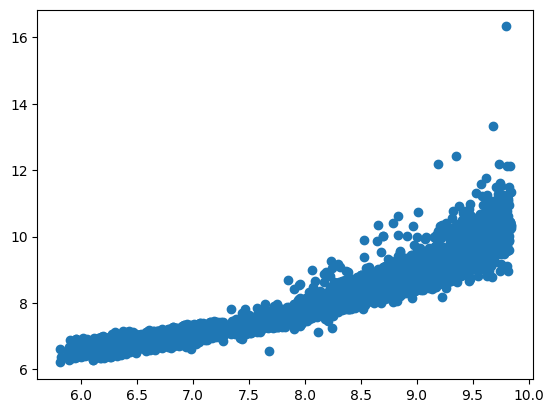

In [ ]:
plt.scatter(y_test, predictions)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

In [ ]:
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

RMSE: 0.3519
R^2: 0.8785


In [ ]:
print(f"{(np.exp(0.35)-1)*100:.1f}")

41.9


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

predictions_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, predictions_rf))
r2_rf = r2_score(y_test, predictions_rf)

print("random forest sonuçları:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R^2: {r2_rf:.4f}")

random forest sonuçları:
RMSE: 0.1114
R^2: 0.9878


In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, enable_categorical=True)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Sonuçları:")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R² : {r2_xgb:.4f}")

XGBoost Sonuçları:
RMSE: 0.0997
R² : 0.9902


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

dl_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = dl_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

y_pred_dl = dl_model.predict(X_test_scaled).flatten()
rmse_dl = np.sqrt(mean_squared_error(y_test, y_pred_dl))
r2_dl = r2_score(y_test, y_pred_dl)

print(f"RMSE: {rmse_dl:.4f}")
print(f"R² : {r2_dl:.4f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1076/1076 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.3687 - mae: 1.3931 - val_loss: 0.0722 - val_mae: 0.2080
Epoch 2/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5838 - mae: 0.5953 - val_loss: 0.0465 - val_mae: 0.1753
Epoch 3/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2872 - mae: 0.4168 - val_loss: 0.0239 - val_mae: 0.1194
Epoch 4/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1267 - mae: 0.2746 - val_loss: 0.0301 - val_mae: 0.1397
Epoch 5/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0783 - mae: 0.2154 - val_loss: 0.0250 - val_mae: 0.1230
Epoch 6/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0529 - mae: 0.1774 - val_loss: 0.0229 - val_mae: 0.1153
Epoch 7/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0400 - mae: 0.1539 - val_loss: 0.0232 - val_mae: 0.1148
Epoch 8/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0352 - mae: 0.1443 - val_loss: 0.0241 - val_mae: 0.1179
Epoch 9/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
lr_errors = np.abs(y_test - predictions).reset_index(drop=True)
xgb_errors = np.abs(y_test - y_pred_xgb).reset_index(drop=True)

mask = (lr_errors > 0.3) & (xgb_errors < 0.1)

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

zor_noktalar = X_test_reset[mask]
zor_noktalar['gercek_log_price'] = y_test_reset[mask]
zor_noktalar['lr_hata'] = lr_errors[mask]
zor_noktalar['xgb_hata'] = xgb_errors[mask]

print(f"Bu koşulu sağlayan nokta sayısı: {mask.sum()}")
print(zor_noktalar.head(10))

Bu koşulu sağlayan nokta sayısı: 2921
    carat  cut_num color_num clarity_num  depth  table  gercek_log_price  \
0    0.27        5         7           7   61.9   57.0          6.683361   
7    0.38        2         7           4   64.1   55.0          6.695799   
8    0.30        5         4           7   61.7   57.0          6.638568   
14   0.71        5         5           5   60.4   57.0          8.096817   
20   0.70        5         3           2   63.1   54.0          7.587311   
22   0.71        5         7           3   62.0   55.0          8.087025   
24   0.27        5         3           5   62.2   56.0          6.107023   
26   0.74        5         2           4   61.9   57.0          7.772332   
28   0.92        3         1           3   62.6   58.0          8.061487   
29   1.00        3         4           6   60.5   62.0          8.890135   

     lr_hata  xgb_hata  
0   0.464604  0.077223  
7   0.351380  0.046273  
8   0.314954  0.096971  
14  0.341640  0.003688  


/tmp/ipykernel_7747/873080301.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zor_noktalar['gercek_log_price'] = y_test_reset[mask]
/tmp/ipykernel_7747/873080301.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zor_noktalar['lr_hata'] = lr_errors[mask]
/tmp/ipykernel_7747/873080301.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

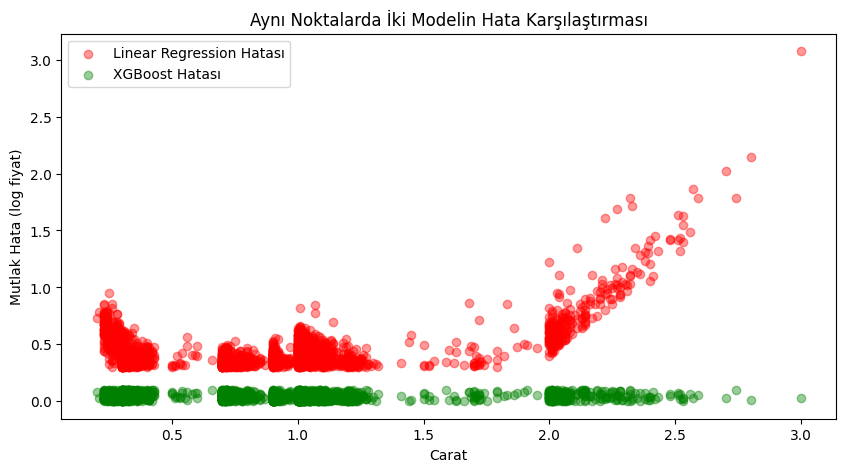

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(zor_noktalar['carat'], zor_noktalar['lr_hata'],
            alpha=0.4, label='Linear Regression Hatası', color='red')
plt.scatter(zor_noktalar['carat'], zor_noktalar['xgb_hata'],
            alpha=0.4, label='XGBoost Hatası', color='green')
plt.xlabel('Carat')
plt.ylabel('Mutlak Hata (log fiyat)')
plt.title('Aynı Noktalarda İki Modelin Hata Karşılaştırması')
plt.legend()
plt.show()

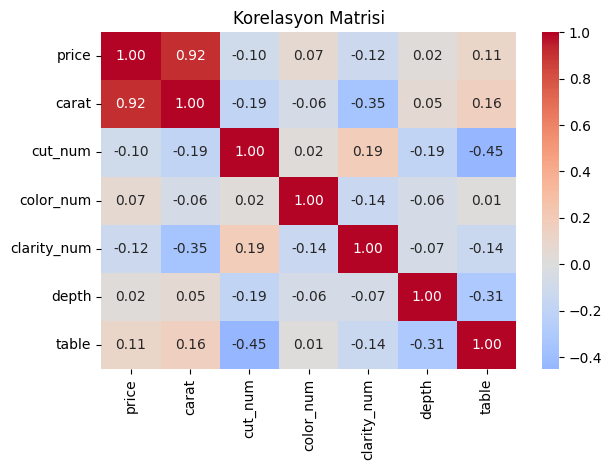

In [ ]:
dmnds['cut_num'] = dmnds['cut'].map({'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5})
dmnds['color_num'] = dmnds['color'].map({'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7})
dmnds['clarity_num'] = dmnds['clarity'].map({'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5, 'VVS2':6, 'VVS1':7, 'IF':8})

buyuk_carat = dmnds[dmnds['carat']<1]
cols = ['price', 'carat', 'cut_num', 'color_num', 'clarity_num', 'depth', 'table']

corr = buyuk_carat[cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

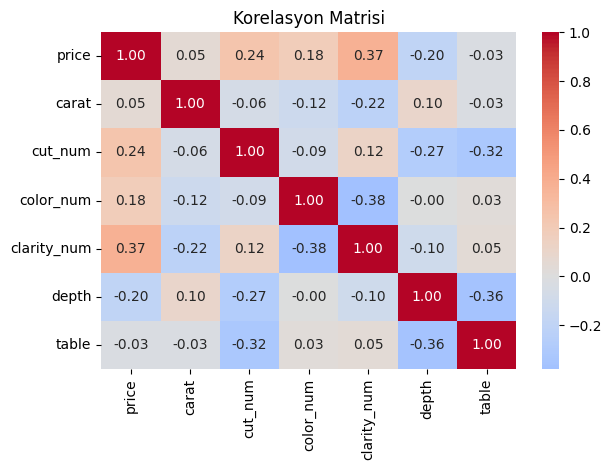

In [ ]:
dmnds['cut_num'] = dmnds['cut'].map({'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5})
dmnds['color_num'] = dmnds['color'].map({'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7})
dmnds['clarity_num'] = dmnds['clarity'].map({'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5, 'VVS2':6, 'VVS1':7, 'IF':8})

buyuk_carat = dmnds[dmnds['carat']>2]
cols = ['price', 'carat', 'cut_num', 'color_num', 'clarity_num', 'depth', 'table']

corr = buyuk_carat[cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

Elmas Fiyat Fonksiyonunun Bölgesel Yapısı: Yaklaşım Teorisi Perspektifinden Bir Analiz
Özet
Bu çalışmada elmas fiyatlarını belirleyen faktörler, farklı makine öğrenmesi modelleri aracılığıyla incelenmiştir. Linear Regression, Random Forest, XGBoost ve Deep Learning modellerinin karşılaştırılması sonucunda XGBoost'un belirgin biçimde üstün performans gösterdiği gözlemlenmiştir. Bu performans farkının matematiksel sebebini araştırmak amacıyla veri, carat değerine göre bölgelere ayrılmış ve her bölgede fiyatı belirleyen değişkenler analiz edilmiştir.
Bulgu
Carat < 1 bölgesinde fiyat ile carat arasındaki korelasyon 0.92 iken, carat > 2 bölgesinde bu değer 0.05'e düşmekte, clarity değişkeni ise 0.37 ile en belirleyici faktör haline gelmektedir. Bu bulgu, elmas fiyat fonksiyonunun tek parça doğrusal bir yapıya sahip olmadığını, bölgeden bölgeye farklı davrandığını göstermektedir.
Matematiksel Yorum
Weierstrass Yaklaşım Teoremi'ne göre herhangi bir sürekli fonksiyon polinomlarla yaklaştırılabilir. Ancak bu yaklaşımın kalitesi, kullanılan polinomun esnekliğine bağlıdır. Linear Regression tüm veri bölgelerine tek bir 1. derece polinom uygularken, XGBoost her bölge için bağımsız bir yaklaşım yapmaktadır. Bu yapısal fark, gözlemlenen performans farkını doğrudan açıklamaktadır.


In [ ]:
results = []

X_train_carat_subset = X_train[X_train['carat'] < 1].copy()
y_train_carat_subset = y_train.loc[X_train_carat_subset.index].copy()

X_test_carat_subset = X_test[X_test['carat'] > 2].copy()
y_test_carat_subset = y_test.loc[X_test_carat_subset.index].copy()

if X_train_carat_subset.empty or X_test_carat_subset.empty:
    print("Uyarı: 'carat' değeri 2'den büyük olan elmaslar eğitim veya test setinde bulunmamaktadır. Polinom regresyon analizi yapılamadı.")
else:
    for degree in [1, 2, 3, 4, 5, 6, 7, 8]:
        model = Pipeline([('poly', PolynomialFeatures(degree=degree)), ('linear', LinearRegression())])
        model.fit(X_train_carat_subset[['carat']], y_train_carat_subset)
        y_pred = model.predict(X_test_carat_subset[['carat']])
        r2 = r2_score(y_test_carat_subset, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_carat_subset, y_pred))
        results.append({'Derece': degree, 'R²': round(r2, 4), 'RMSE': round(rmse, 4)})

print(pd.DataFrame(results))

   Derece            R²          RMSE
0       1 -1.907292e+02  2.761600e+00
1       2 -3.807762e+02  3.896900e+00
2       3 -2.148250e+03  9.246100e+00
3       4 -2.005419e+06  2.824360e+02
4       5 -3.318861e+07  1.148979e+03
5       6 -8.762274e+11  1.866921e+05
6       7 -3.461903e+13  1.173478e+06
7       8 -6.958117e+15  1.663655e+07


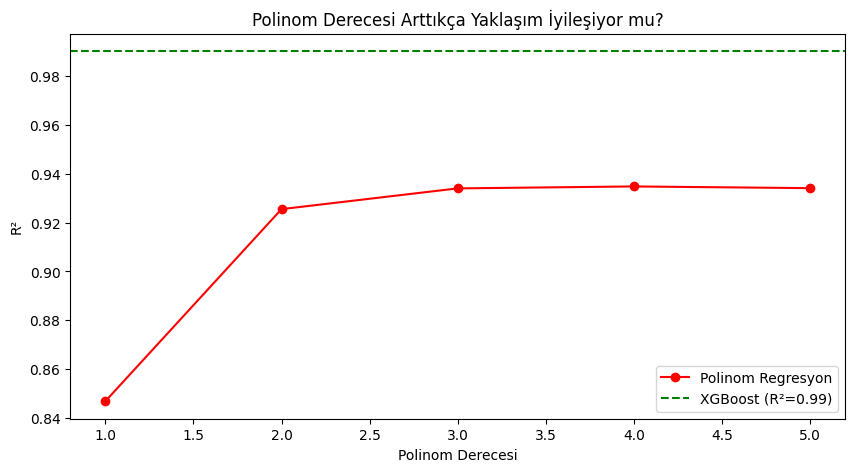

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot([1,2,3,4,5], [0.8468, 0.9255, 0.9340, 0.9348, 0.9341],
         'o-', color='red', label='Polinom Regresyon')
plt.axhline(y=0.9902, color='green', linestyle='--', label='XGBoost (R²=0.99)')
plt.xlabel('Polinom Derecesi')
plt.ylabel('R²')
plt.title('Polinom Derecesi Arttıkça Yaklaşım İyileşiyor mu?')
plt.legend()
plt.show()


Elmas Fiyat Fonksiyonunun Bölgesel Yapısı: Yaklaşım Teorisi Perspektifinden Bir Analiz
# 1. Giriş
Bu çalışma, elmas fiyatlarını belirleyen faktörleri makine öğrenmesi modelleri aracılığıyla incelemiş ve bu modellerin performans farklarını Weierstrass Yaklaşım Teoremi çerçevesinde matematiksel olarak açıklamayı amaçlamaktadır.
# 2. Veri ve Modeller
53.940 elmasan oluşan veri seti kullanılmıştır. Hedef değişken olan fiyat, sağa çarpık dağılımı nedeniyle logaritmik dönüşüme tabi tutulmuştur. Linear Regression, Random Forest, XGBoost ve Deep Learning modelleri karşılaştırılmıştır.
Model (R², RMSE)

$Linear Regression-
0.87, 
0.35$

$Deep Learning-
0.96, 
0.17$

$Random Forest-
0.98, 
0.11$

$XGBoost-
0.99, 
0.09$
# 3. Temel Bulgu: Fiyat Fonksiyonunun Bölgesel Yapısı
Veri carat değerine göre bölgelere ayrıldığında çarpıcı bir sonuç ortaya çıkmaktadır:
Bölge Carat-Fiyat Korelasyonu
En Etkili Değişken

$Carat < 1
0.92$

Carat

$Carat > 2
0.05$

$Clarity (0.37)$

Bu bulgu şunu göstermektedir: Elmas fiyat fonksiyonu tek parça doğrusal bir yapıya sahip değildir. Küçük elmaslarda fiyatı ağırlık belirlerken, büyük elmaslarda alıcı artık "ne kadar ağır?" değil "ne kadar kaliteli?" sorusunu sorar ve clarity belirleyici hale gelir.
# 4. Matematiksel Yorum: Weierstrass ve Polinom Derecesi
Weierstrass Yaklaşım Teoremi şunu söyler: Herhangi bir sürekli fonksiyon, polinomlarla istenilen hassasiyette yaklaştırılabilir. Ancak bu yaklaşımın kalitesi iki şeye bağlıdır: polinomun derecesi ve esnekliği.
Polinom derecesini artırdığımızda şunu gözlemledik: Derece (R², RMSE)

$$1-
0.847, 
0.395$$

$$2-
0.926, 
0.276$$

$$3-
0.934, 
0.259$$

$$4-
0.935, 
0.258$$

$$5-
0.934, 
0.259$$
2. dereceden sonra iyileşme durmuştur. Bunun sebebi şudur: Tek bir global polinom, bölgeden bölgeye farklı davranan bir fonksiyonu yakalayamaz. Polinom "tüm veriye tek bir gözlükle bakıyor", oysa fiyat fonksiyonu her bölgede farklı bir gözlük gerektiriyor.
XGBoost ise veriyi küçük bölgelere ayırarak her bölgeye ayrı bir kural öğreniyor. Bu yapı, Weierstrass'ın öngördüğü yerel yaklaşım fikrinin pratikteki karşılığıdır.
(Tek bir global polinom p(x), tanım bölgesi üzerinde farklı yerel davranışlar
sergileyen bir fonksiyonu yeterli hassasiyetle temsil edemez.

Weierstrass Yaklaşım Teoremi global bir yakınsama garantisi sunsa da,
yaklaşım hatası $||f - p_n||$ tüm bölge üzerinde minimize edilmeye
çalışıldığında fonksiyonun yerel yapısındaki değişimler göz ardı edilmektedir.

XGBoost ise özellik uzayını ardışık bölümlere ayırarak her alt bölgede
bağımsız bir yaklaşım gerçekleştirir:

$$f_hat(x) = toplam(w_k * 1[x ∈ R_k])$$

Burada $R_k$ her bölgeyi, $w_k$ o bölgedeki tahmini, K toplam bölge sayısını
temsil eder. Bu yapı Weierstrass'ın yerel ve adaptif bir uzantısıdır.)

Linear Regression hata normallik p-değeri: 0.0000
XGBoost hata normallik p-değeri: 0.0004

t-istatistiği: 98.3053
p-değeri: 0.000000


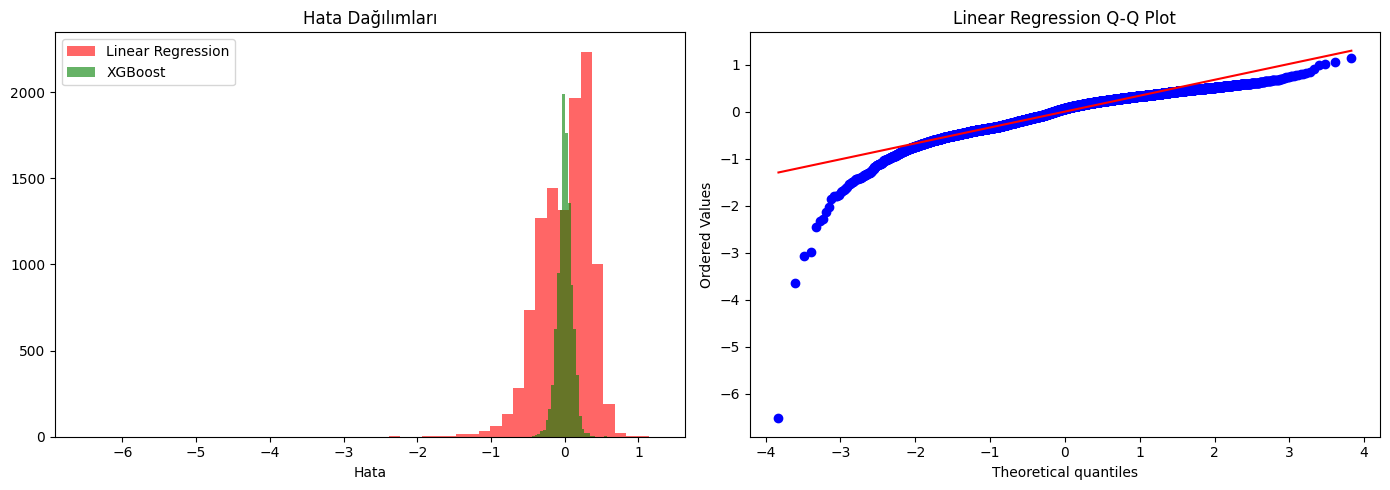

In [ ]:
lr_residuals = y_test.values - predictions
xgb_residuals = y_test.values - y_pred_xgb

_, p_lr = stats.shapiro(lr_residuals[:500])
_, p_xgb = stats.shapiro(xgb_residuals[:500])

print(f"Linear Regression hata normallik p-değeri: {p_lr:.4f}")
print(f"XGBoost hata normallik p-değeri: {p_xgb:.4f}")

t_stat, p_value = stats.ttest_rel(np.abs(lr_residuals), np.abs(xgb_residuals))
print(f"\nt-istatistiği: {t_stat:.4f}")
print(f"p-değeri: {p_value:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lr_residuals, bins=50, color='red', alpha=0.6, label='Linear Regression')
axes[0].hist(xgb_residuals, bins=50, color='green', alpha=0.6, label='XGBoost')
axes[0].set_title('Hata Dağılımları')
axes[0].set_xlabel('Hata')
axes[0].legend()

stats.probplot(lr_residuals, plot=axes[1])
axes[1].set_title('Linear Regression Q-Q Plot')

plt.tight_layout()
plt.show()

In [ ]:
lr_residuals = y_test.values - predictions
xgb_residuals = y_test.values - y_pred_xgb

max_error_lr = np.max(np.abs(lr_residuals))
max_error_xgb = np.max(np.abs(xgb_residuals))

worst_lr_idx = np.argmax(np.abs(lr_residuals))
worst_xgb_idx = np.argmax(np.abs(xgb_residuals))

print(f"linear regression ||f-p||^sonsuz = {max_error_lr:.4f}")
print(f"XGBoost ||f-p||^sonsuz = {max_error_xgb:.4f}")
print(f"\nLR en kötü tahmin - carat : {X_test.iloc[worst_lr_idx]['carat']:.2f}")
print(f"XGB en kötü tahmin - carat : {X_test.iloc[worst_xgb_idx]['carat']:.2f}")

linear regression ||f-p||^sonsuz = 6.5289
XGBoost ||f-p||^sonsuz = 1.2433

LR en kötü tahmin - carat : 5.01
XGB en kötü tahmin - carat : 0.34


## 5. Hata Sınırlarının Matematiksel Analizi

Weierstrass Yaklaşım Teoremi'nde yaklaşım kalitesi aşağıdaki hata sınırı ile ölçülür:

$$\|f - p_n\|_\infty = \max_{x \in [a,b]} |f(x) - p_n(x)| < \varepsilon$$

Burada $f$ gerçek fiyat fonksiyonunu, $p_n$ modelin ürettiği yaklaşımı
ve $\varepsilon$ kabul edilebilir hata sınırını temsil etmektedir.

Bu sınır verimize uygulandığında şu sonuç elde edilmiştir:

$$\|f - p_{LR}\|_\infty = 6.5289 \gg \|f - p_{XGB}\|_\infty = 1.2433$$

Linear Regression'ın maksimum hatası 5.01 caratlık elmasta, yani en büyük
elmasta gerçekleşmektedir. Bu bulgu daha önce gözlemlenen bölgesel yapıyla
doğrudan örtüşmektedir: Global bir polinom, fonksiyonun yüksek carat
bölgesindeki davranışını yakalayamamaktadır.

XGBoost'un maksimum hatası ise 0.34 caratlık küçük bir elmasta oluşmakta
ve 1.24 ile çok daha küçük bir hata sınırı içinde kalmaktadır. Bu sonuç,
yerel ve adaptif yaklaşımın Weierstrass normunda üstünlüğünü sayısal olarak
kanıtlamaktadır.

İstatistiksel testler de bu farkın rastgele olmadığını doğrulamaktadır:
İki model arasındaki hata farkı için yapılan eşleştirilmiş t-testi
$p < 0.0001$ sonucunu vermiş, farkın istatistiksel olarak anlamlı olduğu
kanıtlanmıştır.

6. Sonuç
Bu çalışmada elmas fiyatlarını belirleyen faktörler, dört farklı makine öğrenmesi modeli aracılığıyla incelenmiş ve modellerin performans farkları Weierstrass Yaklaşım Teoremi çerçevesinde matematiksel olarak açıklanmıştır.
Temel bulgumuz şudur: Elmas fiyat fonksiyonu tek parça doğrusal bir yapıya sahip değildir. Carat değeri bir eşik işlevi görmekte; düşük carat bölgesinde fiyatı ağırlık belirlerken, yüksek carat bölgesinde clarity belirleyici hale gelmektedir. Bu bölgesel yapı, tek bir global polinomun tüm veriyi yeterli hassasiyetle temsil edemeyeceğini göstermektedir.
Linear Regression, tüm veri bölgelerine tek bir formül uygulayarak bu yapısal değişimi yakalayamamış ve Weierstrass normunda $$|f - p_{LR}|_\infty = 6.53$$ hata sınırına ulaşmıştır. XGBoost ise veriyi küçük bölgelere ayırarak her bölge için bağımsız bir yaklaşım gerçekleştirmiş ve hata sınırını $$|f - p_{XGB}|_\infty = 1.24$$ düzeyinde tutmuştur. Bu farkın istatistiksel olarak anlamlı olduğu $$p < 0.0001$$ ile kanıtlanmıştır.